# Detecção de fraudes em cartões de crédito

**Objetivo.** Comparar regressão logística, Random Forest e XGBoost para detectar a classe `Class=1` (fraude), com o recall como prioridade, sob um limite explícito de precisão. O notebook inclui alternativas de amostragem, curvas, matriz de confusão e explicações SHAP.

**Dados.** Conjunto *Credit Card Fraud Detection* da ULB/Worldline, carregado diretamente pela [URL usada no tutorial do TensorFlow](https://www.tensorflow.org/tutorials/structured_data/imbalanced_data). O CSV não acompanha o projeto. É necessário acesso à internet para executar a primeira célula de dados.

**Regra de seleção definida antes de ver o teste.** Para cada modelo, escolher no conjunto de validação o limiar de **maior recall** entre aqueles com **precisão de pelo menos 50%**. Se houver empate, preferir maior precisão. Selecionar o modelo principal pelo mesmo critério na validação; usar o teste apenas para relatar o desempenho final. Os 50% são uma hipótese didática de capacidade de investigação: a aplicação real precisaria especificar custos e volume de alertas.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import sklearn
import xgboost

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay, average_precision_score,
    classification_report, confusion_matrix, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 40)
print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__, '| scikit-learn:', sklearn.__version__,
      '| xgboost:', xgboost.__version__, '| shap:', shap.__version__)

Python: 3.12.14
pandas: 2.2.3 | scikit-learn: 1.8.0 | xgboost: 3.4.1 | shap: 0.52.0


## 1. Coleta e exploração

`V1` a `V28` são componentes transformadas por PCA: seus nomes **não** revelam o significado original das variáveis. `Time` mede segundos desde a primeira transação observada, `Amount` é o valor e `Class` é o rótulo. Não há identificador de cartão ou cliente para construir histórico individual confiável.

In [2]:
DATA_URL = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'
df = pd.read_csv(DATA_URL)
expected = {'Time', 'Amount', 'Class', *(f'V{i}' for i in range(1, 29))}
assert set(df.columns) == expected, 'Esquema inesperado no CSV.'
assert set(df['Class'].unique()) == {0, 1}, 'Rótulos inesperados.'
assert df.isna().sum().sum() == 0, 'É preciso tratar valores ausentes.'
assert (df['Amount'] >= 0).all(), 'A transformação log1p pressupõe valor não negativo.'

counts = df['Class'].value_counts().sort_index()
summary = pd.DataFrame({
    'classe': ['normal (0)', 'fraude (1)'],
    'quantidade': counts.to_numpy(),
    'proporção (%)': (100 * counts / len(df)).to_numpy(),
})
print('Formato:', df.shape, '| ausentes:', int(df.isna().sum().sum()))
display(summary.style.format({'proporção (%)': '{:.4f}'}))
print(f'Acurácia da regra "sempre normal": {counts[0] / len(df):.4%}; recall da fraude: 0%.')
display(df[['Time', 'Amount', 'Class', 'V1', 'V2', 'V28']].describe().round(2))

Formato: (284807, 31) | ausentes: 0
Acurácia da regra "sempre normal": 99.8273%; recall da fraude: 0%.


,classe,quantidade,proporção (%)
0,normal (0),284315,99.8273
1,fraude (1),492,0.1727


,Time,Amount,Class,V1,V2,V28
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00,0.00,0.00,-0.00
std,47488.15,250.12,0.04,1.96,1.65,0.33
min,0.00,0.00,0.00,-56.41,-72.72,-15.43
25%,54201.50,5.60,0.00,-0.92,-0.60,-0.05
50%,84692.00,22.00,0.00,0.02,0.07,0.01
75%,139320.50,77.16,0.00,1.32,0.80,0.08
max,172792.00,25691.16,1.00,2.45,22.06,33.85


## 2. Preparação e separação sem vazamento

Criamos `LogAmount = log1p(Amount)` e duas variáveis cíclicas referentes à posição da transação em uma janela de 24 h contada do início da coleta. A fase da coleta **não** identifica o horário civil local. Mantemos `Time` e `Amount` para permitir ao modelo comparar a informação bruta com as transformações.

Os conjuntos têm 60%/20%/20% das linhas, com `stratify` nas duas divisões. `StandardScaler` fica dentro de cada pipeline e é ajustado somente aos dados de treino (ou à amostra extraída deles). Validação e teste preservam a prevalência original.

In [3]:
X = df.drop(columns='Class').copy()
X['LogAmount'] = np.log1p(X['Amount'])
phase = 2 * np.pi * (X['Time'] % 86400) / 86400
X['TimeSin'] = np.sin(phase)
X['TimeCos'] = np.cos(phase)
y = df['Class'].astype(int)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.25,
    stratify=y_trainval, random_state=SEED)
splits = pd.DataFrame([
    {'conjunto': name, 'linhas': len(labels), 'fraudes': int(labels.sum()),
     'taxa de fraude (%)': 100 * labels.mean()}
    for name, labels in [('treino', y_train), ('validação', y_valid), ('teste', y_test)]
])
display(splits.style.format({'taxa de fraude (%)': '{:.4f}'}))
print('Variáveis:', ', '.join(X.columns))

Variáveis: Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, LogAmount, TimeSin, TimeCos


,conjunto,linhas,fraudes,taxa de fraude (%)
0,treino,170883,295,0.1726
1,validação,56962,99,0.1738
2,teste,56962,98,0.1720


## 3. Modelos e duas alternativas de balanceamento

Regressão logística e Random Forest utilizam `class_weight`; XGBoost utiliza a razão entre as classes no **treino** como `scale_pos_weight`. Também avaliamos duas regressões logísticas sem pesos: *undersampling* aleatório de normais (10 normais por fraude) e *oversampling* por duplicação de fraudes (aproximadamente 10% de fraudes na amostra). Duplicação não gera informação nova. **Nenhuma** amostragem afeta a validação ou o teste.

Hiperparâmetros modestos e semente fixa mantêm a execução acessível. Esses resultados não equivalem a uma busca exaustiva nem a probabilidades calibradas.

In [4]:
n_negative = int((y_train == 0).sum())
n_positive = int((y_train == 1).sum())
ratio = n_negative / n_positive

def make_pipeline(estimator):
    return Pipeline([('scaler', StandardScaler()), ('model', estimator)])

models = {
    'Logística (pesos)': make_pipeline(LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED)),
    'Random Forest (pesos)': make_pipeline(RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=2,
        max_samples=0.70, class_weight='balanced_subsample',
        n_jobs=4, random_state=SEED)),
    'XGBoost (pesos)': make_pipeline(XGBClassifier(
        n_estimators=220, max_depth=4, learning_rate=0.08,
        subsample=0.85, colsample_bytree=0.9, min_child_weight=2,
        scale_pos_weight=ratio, objective='binary:logistic',
        tree_method='hist', eval_metric='logloss', n_jobs=4,
        random_state=SEED)),
    'Logística (undersampling)': make_pipeline(LogisticRegression(
        max_iter=1000, random_state=SEED)),
    'Logística (oversampling)': make_pipeline(LogisticRegression(
        max_iter=1000, random_state=SEED)),
}

rng = np.random.default_rng(SEED)
positive_positions = np.flatnonzero(y_train.to_numpy() == 1)
negative_positions = np.flatnonzero(y_train.to_numpy() == 0)
undersampled = np.concatenate([
    positive_positions,
    rng.choice(negative_positions, size=10 * len(positive_positions), replace=False),
])
extra_positive = int(np.ceil(n_negative / 9)) - n_positive
oversampled = np.concatenate([
    np.arange(len(y_train)),
    rng.choice(positive_positions, size=extra_positive, replace=True),
])
train_positions = {
    'Logística (undersampling)': undersampled,
    'Logística (oversampling)': oversampled,
}
print(f'Razão de pesos do XGBoost = {ratio:.2f}:1')
for name, positions in train_positions.items():
    labels = y_train.iloc[positions]
    print(f'{name}: {len(positions):,} amostras, {labels.mean():.2%} fraudes')

for name, model in models.items():
    positions = train_positions.get(name)
    if positions is None:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train.iloc[positions], y_train.iloc[positions])
    print('Treinado:', name)

Razão de pesos do XGBoost = 578.26:1
Logística (undersampling): 3,245 amostras, 9.09% fraudes
Logística (oversampling): 189,543 amostras, 10.00% fraudes
Treinado: Logística (pesos)
Treinado: Random Forest (pesos)
Treinado: XGBoost (pesos)
Treinado: Logística (undersampling)
Treinado: Logística (oversampling)


## 4. Limiar escolhido na validação

Uma probabilidade/pontuação de 0,5 é apenas o padrão convencional. Usamos a curva precisão–recall da **validação** para identificar os limiares que alcançam pelo menos 50% de precisão. Dentre esses, privilegiamos o maior recall da fraude. O teste não entra nessa decisão. Para o cenário real, o piso de precisão teria de refletir a capacidade de análise de alertas e os custos de fraude não detectada.

In [5]:
PRECISION_FLOOR = 0.50

def choose_threshold(labels, scores, precision_floor=PRECISION_FLOOR):
    precision, recall, thresholds = precision_recall_curve(labels, scores)
    feasible = pd.DataFrame({
        'threshold': thresholds,
        'precision': precision[:-1],
        'recall': recall[:-1],
    })
    feasible = feasible[(feasible['precision'] >= precision_floor)
                        & (feasible['recall'] > 0)]
    if feasible.empty:
        raise ValueError('Nenhum limiar atingiu a precisão mínima na validação.')
    best = feasible.sort_values(
        ['recall', 'precision', 'threshold'], ascending=[False, False, False]
    ).iloc[0]
    return float(best['threshold'])

thresholds = {}
validation_scores = {}
validation_rows = []
for name, model in models.items():
    scores = model.predict_proba(X_valid)[:, 1]
    validation_scores[name] = scores
    threshold = choose_threshold(y_valid, scores)
    thresholds[name] = threshold
    predictions = (scores >= threshold).astype(int)
    validation_rows.append({
        'modelo': name,
        'limiar': threshold,
        'recall': recall_score(y_valid, predictions),
        'precisão': precision_score(y_valid, predictions, zero_division=0),
        'F1': f1_score(y_valid, predictions),
        'PR-AUC (AP)': average_precision_score(y_valid, scores),
        'alertas': int(predictions.sum()),
    })
validation_results = pd.DataFrame(validation_rows).sort_values(
    ['recall', 'precisão', 'PR-AUC (AP)'], ascending=False).reset_index(drop=True)
display(validation_results.style.format({
    'limiar': '{:.6f}', 'recall': '{:.4f}', 'precisão': '{:.4f}',
    'F1': '{:.4f}', 'PR-AUC (AP)': '{:.4f}'}))
winner = validation_results.iloc[0]['modelo']
print('Modelo principal selecionado pela VALIDAÇÃO:', winner)
print(f'Limiar correspondente: {thresholds[winner]:.6f}')

Modelo principal selecionado pela VALIDAÇÃO: XGBoost (pesos)
Limiar correspondente: 0.189879


,modelo,limiar,recall,precisão,F1,PR-AUC (AP),alertas
0,XGBoost (pesos),0.189879,0.8283,0.5616,0.6694,0.8062,146
1,Random Forest (pesos),0.149421,0.8182,0.6136,0.7013,0.7719,132
2,Logística (oversampling),0.726363,0.8182,0.5625,0.6667,0.6986,144
3,Logística (pesos),0.995463,0.7980,0.5940,0.6810,0.6825,133
4,Logística (undersampling),0.927377,0.7677,0.5000,0.6056,0.5970,152


## 5. Avaliação única no teste

Aplicamos aos cinco modelos os limiares definidos na validação; comparamos os seus resultados no teste **sem** trocar o modelo selecionado. Recall = fraudes encontradas / fraudes totais. Precisão = fraudes verdadeiras / alertas emitidos. F1 resume ambos; PR-AUC (precisão média) informa qualidade em vários limiares. ROC-AUC é útil, mas a curva precisão–recall mostra melhor a carga de falsos alertas sob prevalência tão baixa.

In [6]:
test_scores = {}
test_rows = []
for name, model in models.items():
    scores = model.predict_proba(X_test)[:, 1]
    test_scores[name] = scores
    predictions = (scores >= thresholds[name]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions, labels=[0, 1]).ravel()
    test_rows.append({
        'modelo': name, 'limiar': thresholds[name],
        'recall': recall_score(y_test, predictions),
        'precisão': precision_score(y_test, predictions, zero_division=0),
        'F1': f1_score(y_test, predictions),
        'ROC-AUC': roc_auc_score(y_test, scores),
        'PR-AUC (AP)': average_precision_score(y_test, scores),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    })
test_results = pd.DataFrame(test_rows)
test_results['selecionado na validação'] = test_results['modelo'].eq(winner)
display(test_results.style.format({
    'limiar': '{:.6f}', 'recall': '{:.4f}', 'precisão': '{:.4f}',
    'F1': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}'}))

selected_scores = test_scores[winner]
selected_predictions = (selected_scores >= thresholds[winner]).astype(int)
print('\nRelatório de classificação do modelo selecionado (teste):')
print(classification_report(y_test, selected_predictions,
                            target_names=['normal', 'fraude'], digits=4))
print('Matriz de confusão [linhas: real 0/1; colunas: previsto 0/1]:')
display(pd.DataFrame(confusion_matrix(y_test, selected_predictions, labels=[0, 1]),
                     index=['real normal', 'real fraude'],
                     columns=['previsto normal', 'previsto fraude']))


Relatório de classificação do modelo selecionado (teste):
              precision    recall  f1-score   support

      normal     0.9998    0.9986    0.9992     56864
      fraude     0.5247    0.8673    0.6538        98

    accuracy                         0.9984     56962
   macro avg     0.7622    0.9330    0.8265     56962
weighted avg     0.9990    0.9984    0.9986     56962

Matriz de confusão [linhas: real 0/1; colunas: previsto 0/1]:


,modelo,limiar,recall,precisão,F1,ROC-AUC,PR-AUC (AP),TP,FP,FN,TN,selecionado na validação
0,Logística (pesos),0.995463,0.8469,0.5804,0.6888,0.9734,0.7206,83,60,15,56804,False
1,Random Forest (pesos),0.149421,0.8673,0.5556,0.6773,0.9616,0.8359,85,68,13,56796,False
2,XGBoost (pesos),0.189879,0.8673,0.5247,0.6538,0.9774,0.8629,85,77,13,56787,True
3,Logística (undersampling),0.927377,0.8469,0.4743,0.6081,0.9711,0.6862,83,92,15,56772,False
4,Logística (oversampling),0.726363,0.8673,0.5215,0.6513,0.9708,0.7498,85,78,13,56786,False


,previsto normal,previsto fraude
real normal,56787,77
real fraude,13,85


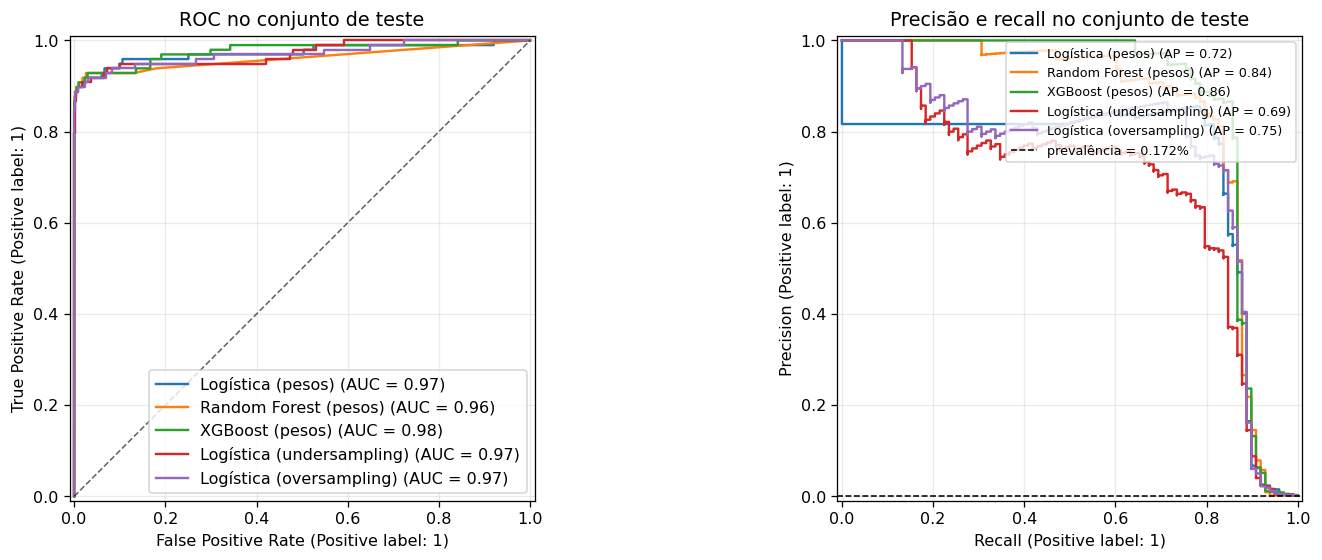

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, scores in test_scores.items():
    RocCurveDisplay.from_predictions(y_test, scores, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(y_test, scores, ax=axes[1], name=name)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=.6)
axes[0].set_title('ROC no conjunto de teste')
axes[1].axhline(y_test.mean(), color='black', linestyle='--', lw=1,
                label=f'prevalência = {y_test.mean():.3%}')
axes[1].set_title('Precisão e recall no conjunto de teste')
axes[1].legend(fontsize=8, loc='upper right')
for ax in axes:
    ax.grid(alpha=.25)
fig.tight_layout()
plt.show()

## 6. Importância e explicação local com SHAP

Explicamos **o modelo selecionado na validação**. Na regressão logística, a importância básica é o módulo dos coeficientes padronizados; nas árvores, a importância interna depende do algoritmo. SHAP permite resumir contribuições e inspecionar uma transação específica. Para regressão logística e XGBoost, as contribuições abaixo estão em **log-odds** (escala bruta do modelo); para Random Forest, em **probabilidade**. Valores positivos elevam a pontuação de fraude em relação ao valor base. A força da contribuição **não** estabelece causalidade, e variáveis `V*` são componentes anonimizadas. O gráfico SHAP agregado usa uma amostra enriquecida com até 30 fraudes e cerca de 90 transações normais; sua média descreve essa amostra explicada, não a prevalência da população.

In [8]:
selected_pipeline = models[winner]
selected_model = selected_pipeline.named_steps['model']
names = X.columns.to_list()
if isinstance(selected_model, LogisticRegression):
    importance = np.abs(selected_model.coef_[0])
    method = '|coeficiente padronizado|'
else:
    importance = selected_model.feature_importances_
    method = 'importância nativa do modelo'
importance_table = pd.DataFrame({'variável': names, method: importance})
display(importance_table.sort_values(method, ascending=False).head(12).reset_index(drop=True))

,variável,importância nativa do modelo
0,V14,0.351624
1,V10,0.132040
2,V4,0.061605
3,Amount,0.039885
4,V20,0.035141
5,V12,0.031279
6,V8,0.027761
7,V17,0.025203
8,V13,0.025174
9,V19,0.022720


Transações explicadas: 120


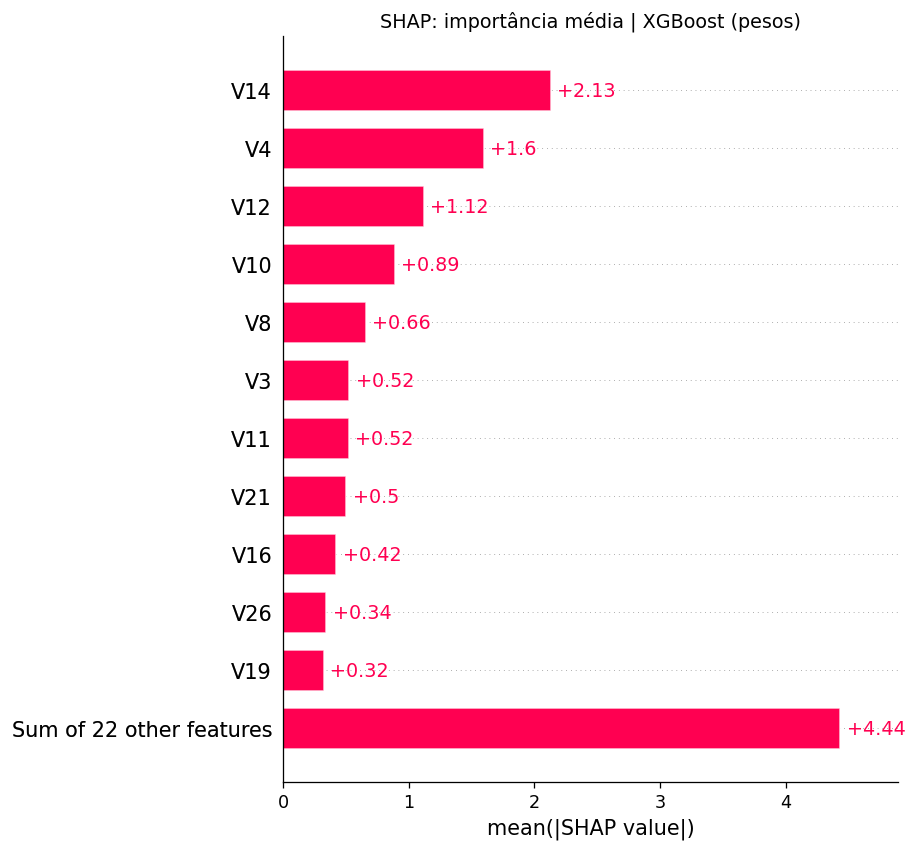

In [9]:
positive_test = np.flatnonzero(y_test.to_numpy() == 1)
normal_test = np.flatnonzero(y_test.to_numpy() == 0)
chosen_correct = positive_test[selected_predictions[positive_test] == 1]
case_position = int(chosen_correct[0]) if len(chosen_correct) else int(np.argmax(selected_scores))
rng_explain = np.random.default_rng(SEED + 1)
explain_positions = np.unique(np.concatenate([
    positive_test[:min(30, len(positive_test))],
    rng_explain.choice(normal_test, size=min(90, len(normal_test)), replace=False),
    np.array([case_position]),
]))
X_explain = X_test.iloc[explain_positions]
Z_explain = pd.DataFrame(selected_pipeline.named_steps['scaler'].transform(X_explain),
                         columns=names, index=X_explain.index)

if isinstance(selected_model, LogisticRegression):
    background = selected_pipeline.named_steps['scaler'].transform(
        X_train.sample(n=100, random_state=SEED))
    explainer = shap.LinearExplainer(selected_model, background)
else:
    explainer = shap.TreeExplainer(selected_model)

shap_values = explainer(Z_explain)
if shap_values.values.ndim == 3:  # Random Forest: saída para classe 0 e classe 1
    shap_values = shap_values[:, :, 1]

print('Transações explicadas:', len(explain_positions))
shap.plots.bar(shap_values, max_display=12, show=False)
plt.title(f'SHAP: importância média | {winner}')
plt.tight_layout()
plt.show()

Transação escolhida: índice original 77348; classe real 1; pontuação 0.999899; limiar 0.189879; alerta 1.


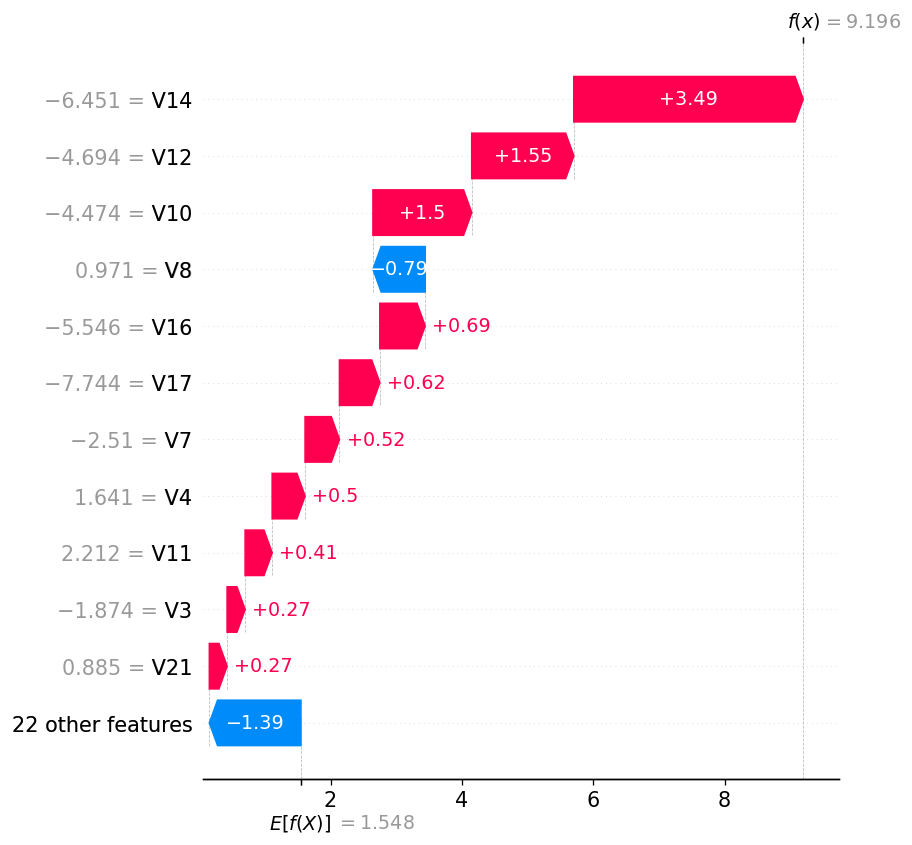

In [10]:
case_index_in_explanation = int(np.flatnonzero(explain_positions == case_position)[0])
print(f'Transação escolhida: índice original {X_test.index[case_position]}; '
      f'classe real {int(y_test.iloc[case_position])}; '
      f'pontuação {selected_scores[case_position]:.6f}; '
      f'limiar {thresholds[winner]:.6f}; '
      f'alerta {int(selected_predictions[case_position])}.')
shap.plots.waterfall(shap_values[case_index_in_explanation], max_display=12, show=False)
plt.tight_layout()
plt.show()

In [11]:
local = pd.Series(shap_values.values[case_index_in_explanation], index=names)
local_top = local.reindex(local.abs().sort_values(ascending=False).head(8).index)
display(pd.DataFrame({'variável': local_top.index, 'valor SHAP': local_top.values,
                      'direção': np.where(local_top.values > 0,
                                          'aumenta o risco estimado',
                                          'reduz o risco estimado')}))
print('Interpretação: essas variáveis alteraram a pontuação deste modelo e desta '
      'transação; os componentes V1–V28 não permitem identificar o comportamento '
      'financeiro subjacente.')

Interpretação: essas variáveis alteraram a pontuação deste modelo e desta transação; os componentes V1–V28 não permitem identificar o comportamento financeiro subjacente.


,variável,valor SHAP,direção
0,V14,3.492701,aumenta o risco estimado
1,V12,1.554496,aumenta o risco estimado
2,V10,1.503892,aumenta o risco estimado
3,V8,-0.794987,reduz o risco estimado
4,V16,0.690271,aumenta o risco estimado
5,V17,0.615108,aumenta o risco estimado
6,V7,0.523312,aumenta o risco estimado
7,V4,0.500980,aumenta o risco estimado


## 7. Limitações e próximos passos

- Apenas 492 fraudes no conjunto completo: métricas variam entre divisões; usar repetição ou validação cruzada apropriada em estudo posterior.
- Divisão aleatória estratificada atende ao case, mas dados de transações costumam exigir **teste temporal** para estimar desempenho futuro e evitar dependência entre momentos próximos.
- Pesos e reamostragem podem distorcer a calibração; as saídas são *scores* para ordenar alertas, não estimativas de risco prontas para uso operacional.
- Variáveis de sequência por cliente exigem identificação do cliente e regras temporais sem olhar o futuro; esses campos não existem nesta base.
- A escolha de 50% de precisão é ilustrativa; um sistema real exigiria custo por fraude, custo de investigação, capacidade de revisão e monitoramento de mudança de distribuição.